# Project 5: Sales Predictions Using Basic Models

**Objective:** Predict future sales using trends.

**Tasks:**
1. Perform basic trend analysis to project next month's sales.
2. Visualize the trend using a line chart.
3. Suggest adjustments based on observed trends.

**Tools:** Python — Pandas, Seaborn, Scikit-learn

## Step 1: Import libraries and load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

sns.set_style('whitegrid')
sns.set_palette('Blues_r')


In [2]:
df = pd.read_csv('product_sales_dataset_final.csv')
df.columns = df.columns.str.strip()
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%m-%d-%y')

df.head()


,Order_ID,Order_Date,Customer_Name,City,State,Region,Country,Category,Sub_Category,Product_Name,Quantity,Unit_Price,Revenue,Profit
0,1,2023-08-23,Bianca Brown,Jackson,Mississippi,South,United States,Accessories,Small Electronics,Phone Case,3,201.01,603.03,221.49
1,2,2024-12-20,Jared Edwards,Grand Rapids,Michigan,Centre,United States,Accessories,Small Electronics,Charging Cable,4,74.30,297.20,97.09
2,3,2024-01-29,Susan Valdez,Minneapolis,Minnesota,Centre,United States,Clothing & Apparel,Sportswear,Nike Air Force 1,1,68.19,68.19,25.47
3,4,2024-11-29,Tina Williams,Tallahassee,Florida,South,United States,Clothing & Apparel,Sportswear,Adidas Tracksuit,3,209.64,628.92,231.38
4,5,2023-09-21,Catherine Gordon,Baltimore,Maryland,East,United States,Accessories,Bags,Backpack,1,216.63,216.63,42.46


## Step 2: Get monthly revenue totals

In [3]:
# group everything by month and add up the revenue
monthly = df.groupby(df['Order_Date'].dt.to_period('M'))['Revenue'].sum()
monthly = monthly.sort_index()
monthly.index = monthly.index.to_timestamp()

print(monthly)


Order_Date
2023-01-01     4379894.64
2023-02-01     2769477.21
2023-03-01     3885192.59
2023-04-01     4347474.27
2023-05-01     4848240.62
2023-06-01     4688298.85
2023-07-01     4515605.37
2023-08-01     4379811.63
2023-09-01     4622595.68
2023-10-01     8677394.98
2023-11-01    13368079.89
2023-12-01    10273306.93
2024-01-01     4367352.84
2024-02-01     2930941.45
2024-03-01     4088588.81
2024-04-01     4263479.24
2024-05-01     4883303.43
2024-06-01     4721684.53
2024-07-01     4367652.54
2024-08-01     4429328.35
2024-09-01     4846454.51
2024-10-01     8719541.99
2024-11-01    13899671.91
2024-12-01    10134372.67
Freq: MS, Name: Revenue, dtype: float64


## Step 3: Plot the monthly revenue trend

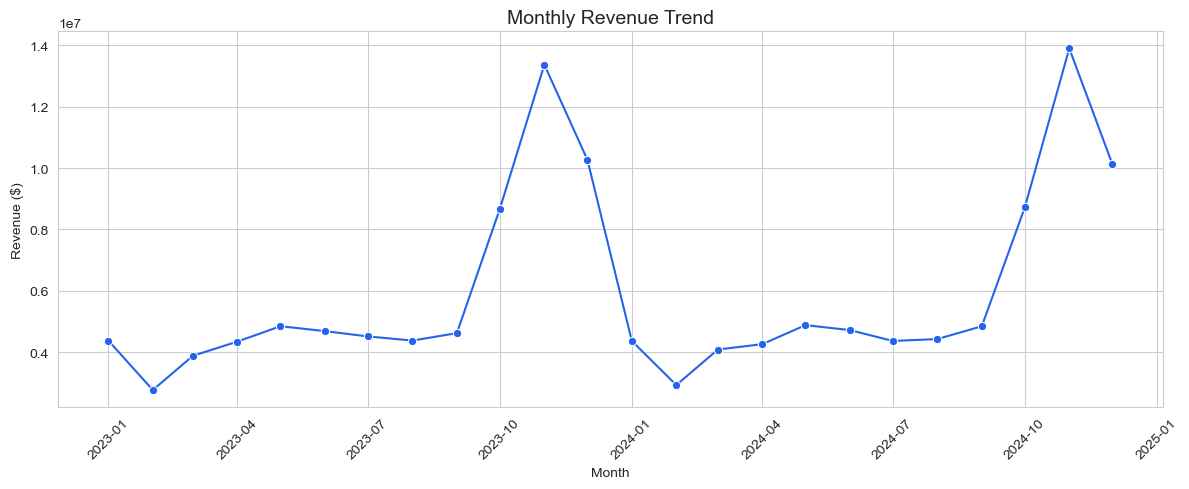

In [4]:
plt.figure(figsize=(12, 5))
sns.lineplot(x=monthly.index, y=monthly.values, marker='o', color='#2563EB')

plt.title('Monthly Revenue Trend', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Step 4: Task 1 — Predict next month's revenue using Random Forest

I used a **Random Forest model** because it can pick up patterns (like seasonality) better than a simple straight-line model. To help the model learn, I gave it the previous month's revenue and the month number as inputs.

In [5]:
# build a table with features the model can learn from
ml_data = pd.DataFrame({'Revenue': monthly.values}, index=monthly.index)
ml_data['Month_Num'] = ml_data.index.month
ml_data['Prev_Month_Revenue'] = ml_data['Revenue'].shift(1)

ml_data = ml_data.dropna()

ml_data.head()


,Revenue,Month_Num,Prev_Month_Revenue
Order_Date,,,
2023-02-01,2769477.21,2,4379894.64
2023-03-01,3885192.59,3,2769477.21
2023-04-01,4347474.27,4,3885192.59
2023-05-01,4848240.62,5,4347474.27
2023-06-01,4688298.85,6,4848240.62


In [6]:
X = ml_data[['Month_Num', 'Prev_Month_Revenue']]
y = ml_data['Revenue']

# keep last few months for testing, no shuffle since this is time-based data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)

print('R2 Score:', round(r2, 3))
print('Average Error (MAE): $', round(mae, 2))


R2 Score: 0.907
Average Error (MAE): $ 762693.2


## Step 5: Task 2 — Visualize actual vs predicted revenue

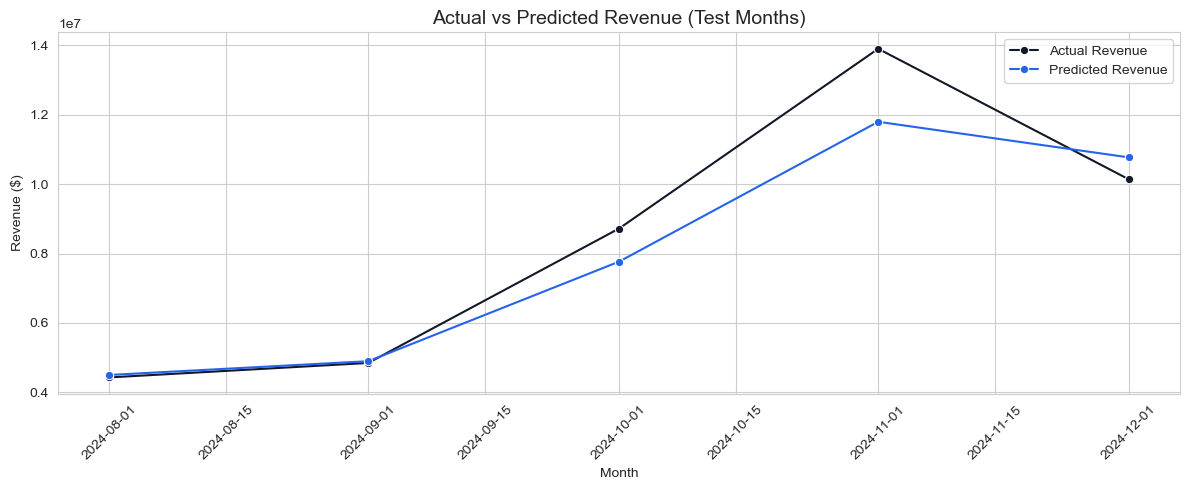

In [7]:
plt.figure(figsize=(12, 5))

sns.lineplot(x=y_test.index, y=y_test.values, marker='o', label='Actual Revenue', color='#111827')
sns.lineplot(x=y_test.index, y=predictions, marker='o', label='Predicted Revenue', color='#2563EB')

plt.title('Actual vs Predicted Revenue (Test Months)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


## Step 6: Predict next month's revenue

In [8]:
# get inputs for next month
last_date = monthly.index[-1]
next_month_num = (last_date.month % 12) + 1
last_revenue = monthly.values[-1]

next_month_input = pd.DataFrame({
    'Month_Num': [next_month_num],
    'Prev_Month_Revenue': [last_revenue]
})

next_month_pred = model.predict(next_month_input)[0]

print('Predicted revenue for next month: $', round(next_month_pred, 2))


Predicted revenue for next month: $ 4416457.53


## Step 7: Average revenue by month (to find best/worst months)

C:\Users\tanishq\AppData\Local\Temp\ipykernel_25224\860822545.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_by_month.index, y=avg_by_month.values, palette='Blues_d')


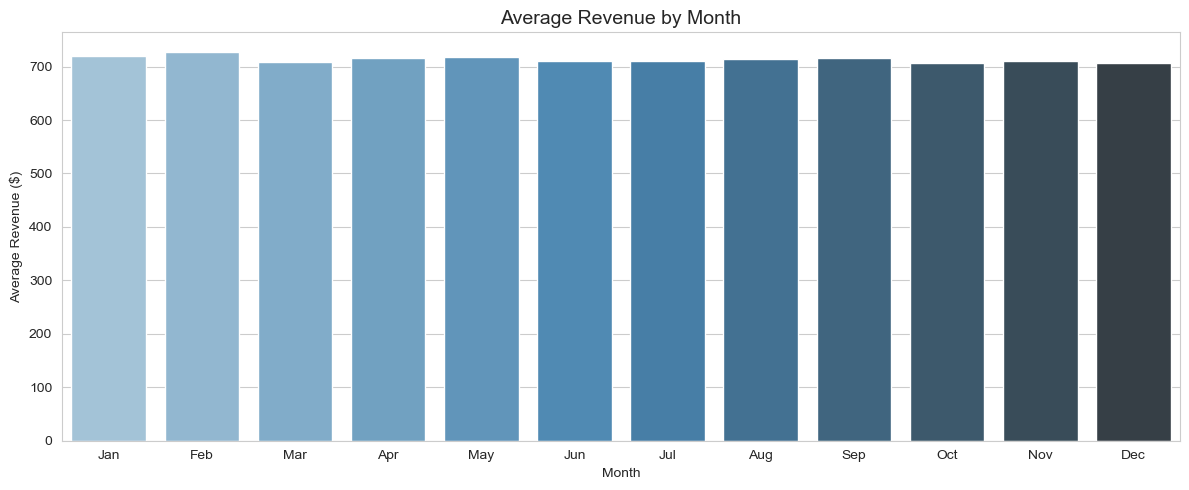

Best month: Feb
Worst month: Oct


In [9]:
df['Month_Name'] = df['Order_Date'].dt.strftime('%b')

avg_by_month = df.groupby('Month_Name')['Revenue'].mean()
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
avg_by_month = avg_by_month.reindex(month_order)

plt.figure(figsize=(12, 5))
sns.barplot(x=avg_by_month.index, y=avg_by_month.values, palette='Blues_d')

plt.title('Average Revenue by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Average Revenue ($)')
plt.tight_layout()
plt.show()

best_month = avg_by_month.idxmax()
worst_month = avg_by_month.idxmin()
print('Best month:', best_month)
print('Worst month:', worst_month)


## Step 8: Task 3 — Suggestions based on observed trends

- Sales are highest around **Nov**, probably due to holiday shopping. The company should increase stock and marketing spend before this month.
- **Feb** tends to be the slowest month, so running discounts or promotions here could help boost sales.
- The Random Forest model takes both the month number and previous month's revenue into account, so it should capture some of the seasonal pattern seen above.
- The R² score and average error (MAE) printed in Step 4 show how reliable this prediction is — a higher R² (closer to 1) and lower MAE means better predictions.